In [1]:
%reload_ext autoreload
%autoreload 2

from src.backtest import Backtest, Filter, Univ
from src.pattern import Pattern, Bollinger, High, GoldenCross, Trending, Disparity, MFI, Regime, SizeBucket

# 기본설정

In [2]:
start = "2000-01-01"
end = "2025-12-31"
univ = Univ(market=["KOSPI", 'KOSDAQ'])
bm = Pattern(name='모든주식')
bt = Backtest(start, end, benchmark=bm, by='day', univ=univ, db=0)

모든주식 | trim: 100%|██████████| 6409/6409 [00:08<00:00, 741.87it/s] 


볼린저돌파 | trim: 100%|██████████| 6409/6409 [00:00<00:00, 31563.97it/s]
볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | trim: 100%|██████████| 6409/6409 [00:00<00:00, 46538.19it/s]


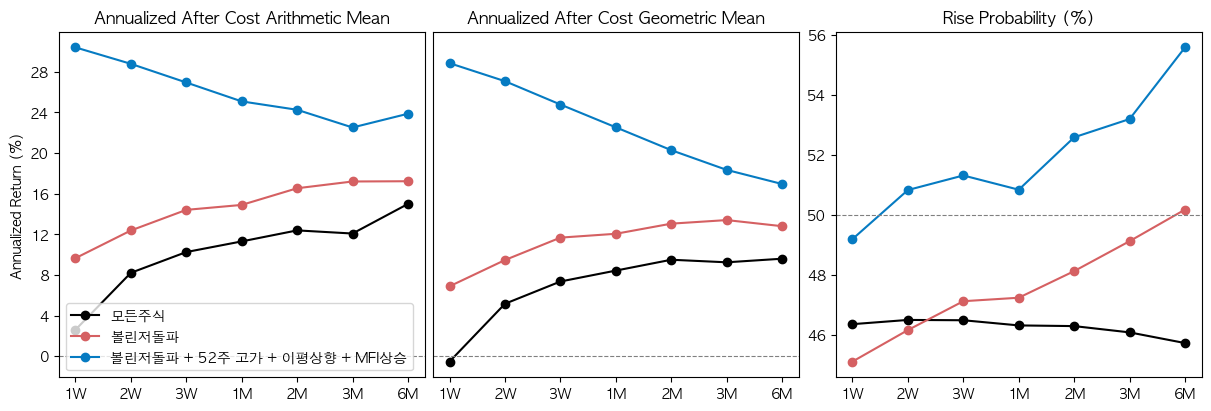

In [3]:
filter = Filter(market_cap=[])#, liquidity=[1,2,3,4,5], order=['market_cap', 'liquidity'])

uptrend = Trending(name='이평상향').on(trigger='ma_trend_up', window=200)
mfi_high = MFI(name='MFI상승').on(trigger='above', threshold=50)

bb = Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05)
high52w = High(name='52주 고가').on(window=240, threshold=0.90, stay_days=1)
bb_high52w = bb + high52w + uptrend + mfi_high
stats = bt.analyze(bb, bb_high52w, filter=filter)
stats.plot(annualized=True)

볼린저돌파 | trim: 100%|██████████| 6409/6409 [00:00<00:00, 33188.34it/s]
볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | trim: 100%|██████████| 6409/6409 [00:00<00:00, 59945.89it/s]


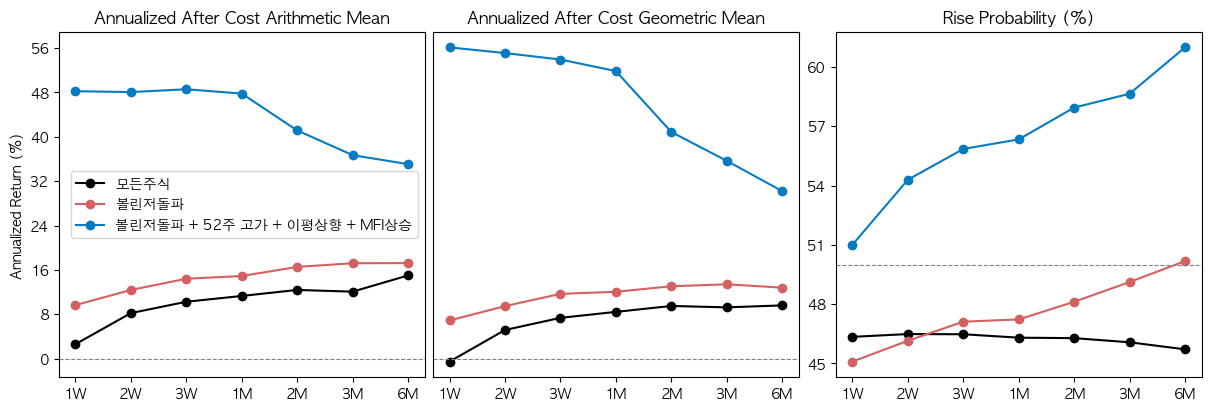

In [4]:
filter = Filter(market_cap=[])#, liquidity=[1,2,3,4,5], order=['market_cap', 'liquidity'])
regime = Regime(name='강세장').on(kind='broad_bull_breakout', market='kospi')

uptrend = Trending(name='이평상향').on(trigger='ma_trend_up', window=200)
mfi_high = MFI(name='MFI상승').on(trigger='above', threshold=50)

bb = Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05)
high52w = High(name='52주 고가').on(window=240, threshold=0.90, stay_days=1)
bb_high52w = (bb + high52w + uptrend + mfi_high).when(regime)
stats = bt.analyze(bb, bb_high52w, filter=filter)
stats.plot(annualized=True)

볼린저돌파 + 52주 고가 | 볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | 볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 + 대형주 | trim: 100%|██████████| 6409/6409 [00:00<00:00, 48621.89it/s]


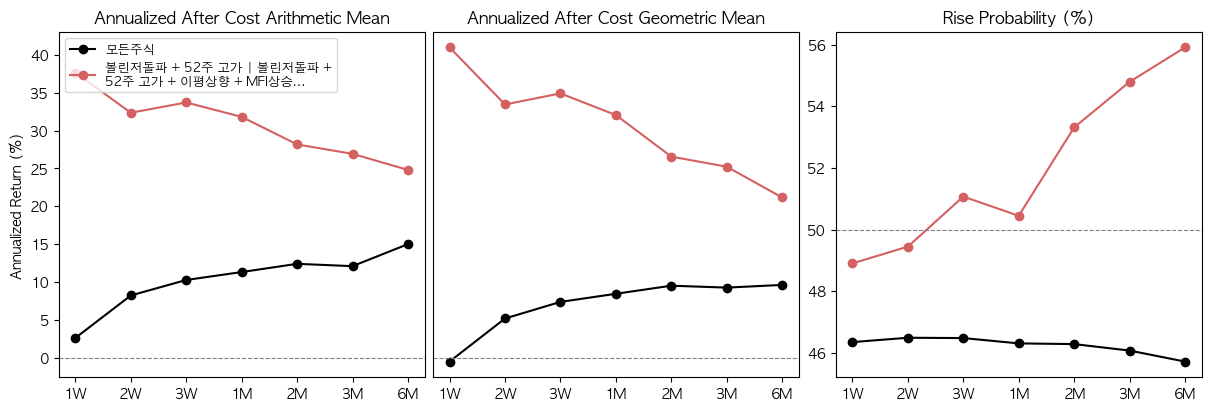

In [11]:
filter = Filter(market_cap=[])#, liquidity=[1,2,3,4,5], order=['market_cap', 'liquidity'])

reg_broad = Regime().on(kind='broad_bull_breakout', market='kospi')
reg_quiet = Regime().on(kind='quiet_squeeze_expansion', market='kospi')
reg_narrow = Regime().on(kind='narrow_leadership', market='kospi')

uptrend = Trending(name='이평상향').on(trigger='ma_trend_up', window=200)
mfi_high = MFI(name='MFI상승').on(trigger='above', threshold=50)

bb = Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.15)
bb_squeeze = Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05)
high52w = High(name='52주 고가').on(window=240, threshold=0.90, stay_days=1)
large = SizeBucket(name='대형주').on(bucket='large')

pat = (
    (bb + high52w).when(reg_broad)
    | (bb_squeeze + high52w + uptrend + mfi_high).when(reg_quiet)
    | (bb + high52w + uptrend + mfi_high + large).when(reg_narrow)
)

stats = bt.analyze(pat)
stats.plot(annualized=True)

볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | run: 100%|██████████| 6408/6408 [00:02<00:00, 2776.07it/s]


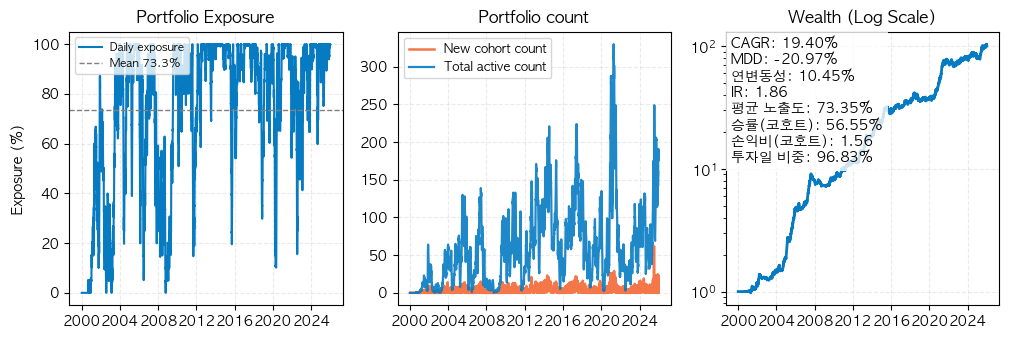

In [4]:
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가 + 이평상향 + MFI상승",
    target_horizon=20,
    trade_price_mode='당일종가'
)
simul.plot()

볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | run: 100%|██████████| 6408/6408 [00:00<00:00, 8089.86it/s] 


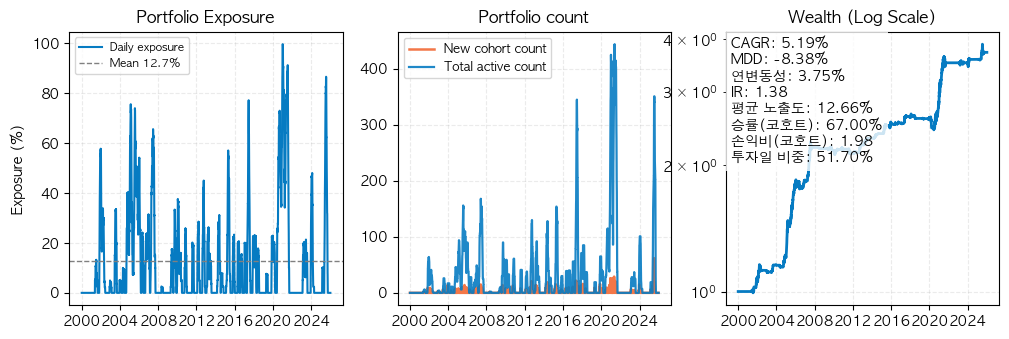

In [6]:
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가 + 이평상향 + MFI상승",
    target_horizon=40,
    trade_price_mode='당일종가'
)
simul.plot()

볼린저돌파 + 52주 고가 | 볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | 볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 + 대형주 | run: 100%|██████████| 6408/6408 [00:00<00:00, 27573.86it/s]


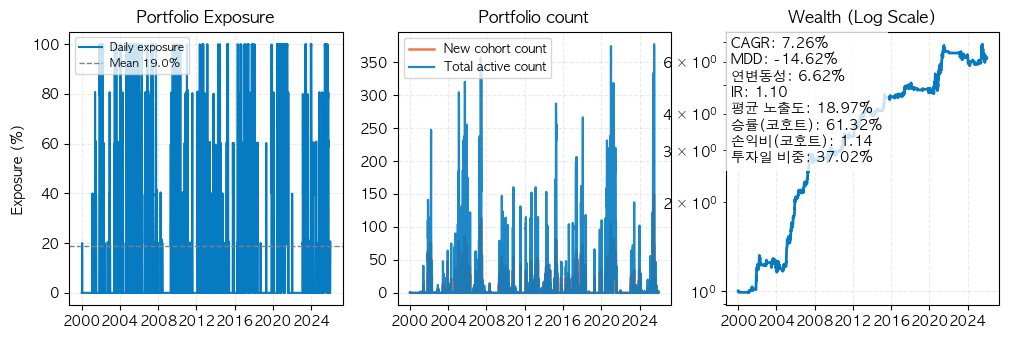

In [15]:
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가 | 볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 | 볼린저돌파 + 52주 고가 + 이평상향 + MFI상승 + 대형주",
    target_horizon=5,
    trade_price_mode='당일종가'
)
simul.plot()